In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Concentration and Generalization

Every guarantee this chapter has offered so far decays *polynomially*.
Chebyshev's inequality the equation caps the miss probability of a
sample mean at $\sigma^2/(nt^2)$, a rate of $1/n$, and the tests and
confidence intervals of that section traded that finite-sample
bound away for Gaussian *approximations* that are only exact in the limit. The
truth is far better: when the data are bounded, the probability that an
average strays from its mean decays *exponentially* in $n$, and this section
proves it. The main book bounded the error of a test-set
estimate with Hoeffding's inequality (that section),
quoting it on faith; here we prove it. The same machinery
then explains the strange geometry of high dimension teased in
that section (thin shells, near-orthogonal random
directions) and carries us to
the question all of it serves: *generalization*. A learner that picks its
function after seeing the data voids the single-function guarantee, and the
repair (uniform convergence, first over finite classes and then through
Rademacher complexity) is the promised mechanics behind the classical
generalization bounds of that section. The section closes
where the classical story visibly breaks and something more interesting
appears: interpolation and *double descent*, reproduced from scratch in
twenty-six lines and explained by the very quantity that the Rademacher
calculation says is the true capacity knob: the norm of the solution.

Every computation in this section is a matter of tails, norms, and least
squares, so the worked cells below use plain NumPy, imported as `onp`, with
`d2l` for plotting.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
import numpy as onp  # the worked cells compute with plain NumPy

## From Chebyshev to Chernoff

### Polynomial Tails Are Not Enough

Recall the ladder built in that section. Markov's
inequality the equation turns a bare mean into a tail bound; feeding
it the squared deviation sharpens it into Chebyshev's inequality
the equation. Applied to a sample mean $\bar X$ of $n$ i.i.d.
draws with variance $\sigma^2$, Chebyshev gives

$$
P\bigl(|\bar X - \mu| \ge t\bigr) \le \frac{\sigma^2}{n\,t^2},
$$

and this was enough to prove consistency in that section. But
look at what it takes. To certify a miss probability of $10^{-6}$ at fixed $t$
we must grow $n$ by a factor of a *million* relative to certifying $10^{0}$:
the bound decays only like $1/n$. Meanwhile the exact tail of, say, a fair
coin's head-frequency collapses *exponentially* fast; we will compute it
below and watch Chebyshev fall behind by eight orders of magnitude at
$n=1{,}000$ and about forty-three at $n=5{,}000$. The
Gaussian machinery of that section (the $z$-test, the
$1.96\,\hat\sigma/\sqrt n$ interval) implicitly knows this, since Gaussian
tails decay like $e^{-t^2/2}$, but it gets the rate from an approximation that
is only exact as $n\to\infty$. What we want is a bound with the *Gaussian
rate* and the *finite-sample validity* of Chebyshev. The obstruction is easy to
name: Chebyshev sees only the second moment. A tail bound that decays like
$e^{-ct^2}$ must see *every* moment at once, and there is a single function
that packages them all.

### The Chernoff Method

The *moment generating function* (MGF) of a random variable $X$ is
$M(\lambda)=E[e^{\lambda X}]$; expanding the exponential shows its Taylor
coefficients are the moments $E[X^k]$ scaled by $1/k!$, so bounding $M$ bounds
every moment simultaneously. The *Chernoff method* is Markov's inequality
applied not to $X$ but to $e^{\lambda X}$ (a monotone transform, so the event
is unchanged), followed by an optimization over the free parameter: for any
$\lambda>0$,

$$
P(X \ge t)
 = P\bigl(e^{\lambda X} \ge e^{\lambda t}\bigr)
 \le e^{-\lambda t}\,E\bigl[e^{\lambda X}\bigr],
\qquad\textrm{hence}\qquad
P(X \ge t) \le \inf_{\lambda > 0}\, e^{-\lambda t}\, M(\lambda).
$$

That is the whole method. Its power appears the moment $X$ is a *sum* of
independent terms: the MGF of a sum factors into a *product* of MGFs (the
expectation of a product of independent variables is the product of
expectations), so the exponent in the equation grows linearly in
$n$, and optimizing $\lambda$ then turns that linear-in-$n$ exponent into the
exponential decay we are after. Everything below is this one display with a
good bound on the MGF plugged in. For bounded variables the sharpest generic
MGF bound is a lemma of Hoeffding; we prove it carefully because it is the
engine of the whole section.

### Hoeffding's Lemma and Hoeffding's Inequality

**Proposition (Hoeffding's lemma).** *Let $X$ be a random variable with
$E[X]=0$ taking values in $[a,b]$. Then for every $\lambda\in\mathbb{R}$,*

$$
E\bigl[e^{\lambda X}\bigr] \le \exp\!\left(\frac{\lambda^2 (b-a)^2}{8}\right).
$$

**Proof.** Let $\psi(\lambda)=\log E[e^{\lambda X}]$, the cumulant generating
function; for bounded $X$ it is finite and smooth, and differentiating under
the expectation is routine. Then $\psi(0)=0$, and

$$
\psi'(\lambda) = \frac{E[X e^{\lambda X}]}{E[e^{\lambda X}]},
\qquad\textrm{so}\qquad
\psi'(0) = E[X] = 0 .
$$

The first derivative has a probabilistic reading that does all the work:
$\psi'(\lambda)$ is the mean of $X$ under the *tilted* distribution
$p_\lambda(x) \propto e^{\lambda x}\,p(x)$, a genuine probability
distribution still supported inside $[a,b]$. Differentiating once more,

$$
\psi''(\lambda)
 = \frac{E[X^2 e^{\lambda X}]}{E[e^{\lambda X}]}
 - \left(\frac{E[X e^{\lambda X}]}{E[e^{\lambda X}]}\right)^{\!2}
 = \operatorname{Var}_{\lambda}(X),
$$

the variance of $X$ under the tilt. Now use the fact that *any* random
variable $Y$ supported in $[a,b]$ has variance at most $(b-a)^2/4$: variance
is the smallest expected squared deviation over all centers (the mean
minimizes it), and every point of $[a,b]$ lies within $(b-a)/2$ of the
midpoint, so

$$
\operatorname{Var}(Y)
 \le E\!\left[\Bigl(Y - \tfrac{a+b}{2}\Bigr)^{\!2}\right]
 \le \left(\frac{b-a}{2}\right)^{\!2}.
$$

Hence $\psi''(\lambda) \le (b-a)^2/4$ for *every* $\lambda$. Taylor's theorem
with Lagrange remainder finishes it: for some $\xi$ between $0$ and $\lambda$,

$$
\psi(\lambda)
 = \psi(0) + \lambda\,\psi'(0) + \frac{\lambda^2}{2}\,\psi''(\xi)
 \le \frac{\lambda^2 (b-a)^2}{8},
$$

and exponentiating gives the equation. $\blacksquare$

The lemma says a bounded, centered variable has an MGF *no worse than a
Gaussian's* with standard deviation $(b-a)/2$: compare the Gaussian identity
$E[e^{\lambda X}]=e^{\lambda^2\sigma^2/2}$ for $X\sim\mathcal N(0,\sigma^2)$,
an integral done by completing the square. Feeding the lemma into
the Chernoff method yields Hoeffding's inequality, in four lines.

**Proposition (Hoeffding's inequality).** *Let $X_1,\ldots,X_n$ be independent
random variables with $X_i\in[a,b]$, and let $\bar X = \frac1n\sum_i X_i$.
Then for every $t>0$,*

$$
P\bigl(|\bar X - E[\bar X]| \ge t\bigr)
 \le 2\exp\!\left(-\frac{2 n t^2}{(b-a)^2}\right).
$$

**Proof.** Write $Z_i = X_i - E[X_i]$; each is centered and supported in an
interval of length $b-a$, so the lemma applies. For any $\lambda>0$, Chernoff
the equation plus independence (the MGF of the sum is the product
of MGFs) gives

$$
P(\bar X - E[\bar X] \ge t)
 = P\Bigl(\sum_i Z_i \ge nt\Bigr)
 \le e^{-\lambda n t} \prod_{i=1}^n E\bigl[e^{\lambda Z_i}\bigr]
 \le \exp\!\left(-\lambda n t + \frac{n\lambda^2 (b-a)^2}{8}\right).
$$

The exponent is a parabola in $\lambda$, minimized at
$\lambda = 4t/(b-a)^2$, where its value is $-2nt^2/(b-a)^2$. Applying the same
argument to $-Z_i$ bounds the lower tail identically, and the *union bound*
(the probability that at least one of several events occurs is at most the
sum of their probabilities) applied to the two tails supplies the factor $2$.
$\blacksquare$

This is the inequality of [@Hoeffding.1963], and it pays the main book's
debt. that section used exactly
the equation (with losses in $[0,1]$, so $b-a=1$) to certify a
test-set estimate of the error rate: demanding
$P(|\epsilon_{\mathcal D}(f)-\epsilon(f)|\ge 0.01)\le 0.05$ and solving
$2e^{-2nt^2}\le\delta$ for $n$ gives $n = \log(2/\delta)/(2t^2) \approx
18{,}445$: the "roughly 18,500 examples" quoted there, now a theorem rather
than a citation. Note what the bound does *not* need: no Gaussianity, no
variance estimate, no asymptotics. It needs only boundedness and independence,
and it holds at every finite $n$.

Inverting the inequality gives the form a practitioner actually reaches for.
Set the right-hand side of the equation equal to $\delta$ and
solve for $t$: with probability at least $1-\delta$,

$$
\bigl|\bar X - E[\bar X]\bigr|
 \le (b-a)\sqrt{\frac{\log(2/\delta)}{2n}} .
$$

This is a *finite-sample confidence interval* in the exact sense of
that section, with the same $1/\sqrt n$ half-width scaling as
the Gaussian interval the equation. But where that
interval's coverage was asymptotic (and, as the coverage audit there measured,
slightly optimistic at finite $n$), this one is a guarantee at every $n$. The
trade-off is the constant: Hoeffding allows for the most adversarial
distribution
on $[a,b]$, so the range $b-a$ stands where the Gaussian interval enjoys the
estimated $\hat\sigma$, and when the true spread is much smaller than the
range the interval is correspondingly conservative, slack that Bernstein's
inequality, below, is designed to recover. Keep
the equation in view; it is the statement we will
upgrade from one function to entire function classes in the second half of
the section.

### Sub-Gaussian and Sub-Exponential Variables

The proof used only one property of the summands: an MGF bounded by a
Gaussian's. That property deserves a name, because it is the right abstraction
for everything that follows. A random variable $X$ is **sub-Gaussian** with
*variance proxy* $\sigma^2$ if

$$
E\bigl[e^{\lambda (X - E[X])}\bigr] \le \exp\!\left(\frac{\lambda^2\sigma^2}{2}\right)
\qquad\textrm{for all } \lambda\in\mathbb{R}.
$$

The Chernoff method converts the equation directly into the
two-sided tail $P(|X-E[X]|\ge t)\le 2e^{-t^2/(2\sigma^2)}$, by the same
optimization as above. Three families matter to us. A *Gaussian*
$\mathcal N(\mu,\sigma^2)$ is sub-Gaussian with proxy exactly $\sigma^2$ (the
MGF identity holds with equality). A *bounded* variable on $[a,b]$ is
sub-Gaussian with proxy $(b-a)^2/4$; that is Hoeffding's lemma. And a
*Rademacher* variable, a uniform random sign $\varepsilon\in\{-1,+1\}$, is
sub-Gaussian with proxy $1$: $E[e^{\lambda\varepsilon}]=\cosh\lambda\le
e^{\lambda^2/2}$, a term-by-term comparison of Taylor series left as exercise
1. Sub-Gaussianity is closed under averaging: if $X_1,\ldots,X_n$ are
independent with proxy $\sigma^2$, then $\bar X$ is sub-Gaussian with proxy
$\sigma^2/n$ (the MGF product argument again), so *every* sub-Gaussian
average concentrates at the Hoeffding rate.

Not everything is sub-Gaussian. The *square* of a Gaussian (a $\chi^2$
variable, hence squared norms of Gaussian vectors) has a right tail decaying
like $e^{-t/2}$, too heavy for the equation: its MGF is finite
only for $\lambda<\tfrac12$, so no bound of the form
the equation, which must hold for *all* $\lambda$, is possible.
Such variables are called **sub-exponential**: $X$ is sub-exponential with
parameters $(\nu,\alpha)$ if

$$
E\bigl[e^{\lambda (X - E[X])}\bigr] \le \exp\!\left(\frac{\lambda^2\nu^2}{2}\right)
\qquad\textrm{for } |\lambda| \le \frac{1}{\alpha},
$$

a Gaussian-type MGF bound restricted to a window of $\lambda$. The Chernoff
optimization then splits at the window's edge: small deviations use an
interior $\lambda$ and get a Gaussian rate, while large deviations clamp
$\lambda$ at $1/\alpha$ and get an exponential (not squared-exponential)
rate. **Bernstein's inequality** packages both regimes: if the $X_i$ are
independent with
$\operatorname{Var}(X_i)\le\sigma^2$ and $|X_i - E[X_i]|\le M$, then

$$
P\bigl(|\bar X - E[\bar X]| \ge t\bigr)
 \le 2\exp\!\left(-\frac{n t^2}{2\bigl(\sigma^2 + M t/3\bigr)}\right),
$$

which we state without proof [@Boucheron.Lugosi.Massart.2013]. Read it as
the variance-aware refinement of Hoeffding: for small $t$ the denominator is
essentially $2\sigma^2$ and the bound matches the CLT's Gaussian tail with the
*true* variance, often far smaller than the worst case $(b-a)^2/4$ that
Hoeffding must assume, while for large $t$ the $Mt/3$ term takes over and the
decay is exponential in $t$, which is the best a bounded-but-skewed sum can
do. We will lean on exactly this small-deviation sharpness when we prove norm
concentration below.

### The Tail Race in Code

Claims about rates deserve a measurement. For the fair coin we can compute the
tail $P(|\hat p - \tfrac12| \ge 0.1)$ *exactly* (a finite binomial
sum, which we evaluate in log-space so that $n=5{,}000$ does not underflow)
and race it against Chebyshev ($\sigma^2=\tfrac14$, so the bound is
$25/n$ at $t=0.1$) and Hoeffding ($2e^{-2nt^2}=2e^{-0.02n}$). No sampling is
involved; every number below is deterministic.

     n      exact  Chebyshev  Hoeffding
    10   7.54e-01   2.50e+00   1.64e+00
   100   5.69e-02   2.50e-01   2.71e-01
  1000   2.73e-10   2.50e-02   4.12e-09
  5000   1.30e-45   5.00e-03   7.44e-44


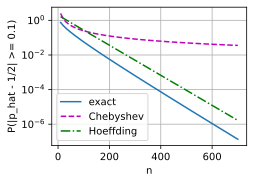

In [2]:
t = 0.1  # deviation of the head-frequency from 1/2

def exact_tail(n):  # P(|p_hat - 1/2| >= t): binomial sum in log-space
    k = onp.arange(n + 1)
    log_pmf = n * onp.log(0.5) + onp.concatenate(
        ([0.0], onp.cumsum(onp.log((n - k[1:] + 1) / k[1:]))))
    in_tail = log_pmf[onp.abs(k / n - 0.5) >= t - 1e-12]  # fp-safe boundary
    m = in_tail.max()
    return onp.exp(m) * onp.exp(in_tail - m).sum()  # stable log-sum-exp

print(f'{"n":>6} {"exact":>10} {"Chebyshev":>10} {"Hoeffding":>10}')
for n in (10, 100, 1000, 5000):
    print(f'{n:6d} {exact_tail(n):10.2e} {0.25 / (n * t**2):10.2e} '
          f'{2 * onp.exp(-2 * n * t**2):10.2e}')

ns = onp.arange(10, 701, 10)
d2l.plot(ns, [onp.array([exact_tail(n) for n in ns]),
              0.25 / (ns * t**2), 2 * onp.exp(-2 * ns * t**2)],
         'n', 'P(|p_hat - 1/2| >= 0.1)',
         legend=['exact', 'Chebyshev', 'Hoeffding'], yscale='log')

At $n=10$ both
bounds are vacuous (above $1$) while the exact tail is $0.75$: nothing
concentrates in ten flips. At $n=100$ Chebyshev ($0.25$) is actually a shade
*tighter* than Hoeffding ($0.27$): for small $n$ the comparison is between
constants, and Chebyshev's use of the true variance $\tfrac14$ helps it. But
rates always beat constants. By $n=1{,}000$ the exact tail is
$2.7\times10^{-10}$ and Hoeffding certifies $4.1\times10^{-9}$, within a
factor of about $15$ (one order of magnitude), while Chebyshev still allows a
miss probability of
$2.5\%$, off by *eight orders of magnitude*; at $n=5{,}000$ the gap has grown
to about forty-three orders. The log-scale plot makes the geometry plain: the
exact tail
and Hoeffding's bound are parallel straight lines (exponential decay;
Hoeffding's exponent $2t^2=0.02$ is close to the optimal rate,
which *large-deviations theory* identifies as the Kullback--Leibler divergence
$\mathrm{KL}(0.6\,\|\,0.5)\approx 0.0201$, an information-theoretic measure of
how distinguishable two distributions are; that section
develops both), while Chebyshev's gentle curve is
polynomial decay that no constant can rescue.

## Probability in High Dimension

Concentration governs more than sample means over datasets. The coordinates of
a random *vector* are also "many independent contributions", so the same
inequalities govern the geometry of high-dimensional space, and that geometry
is where deep learning lives. The phenomenon has a name: **concentration of
measure**, the fact that in high dimension any sufficiently well-behaved
function of many independent coordinates is nearly constant, with fluctuations
exponentially rare. This section quantifies it.
that section stated two facts
while cataloguing the multivariate Gaussian: the norm of a
$d$-dimensional standard Gaussian locks onto $\sqrt d$, and two independent
draws are nearly orthogonal. Here we give both facts their quantitative
treatment.

### Norm Concentration

**Proposition (norm concentration).** *Let
$\mathbf x\sim\mathcal N(\mathbf 0,\mathbf I_d)$. For every $0<\varepsilon\le 1$,*

$$
P\!\left(\Bigl|\frac{\|\mathbf x\|}{\sqrt d} - 1\Bigr| \ge \varepsilon\right)
 \le 2\exp\!\left(-\frac{d\,\varepsilon^2}{8}\right).
$$

**Proof sketch.** The squared norm $\|\mathbf x\|^2=\sum_{i=1}^d x_i^2$ is a
sum of $d$ i.i.d. variables $x_i^2$ with mean $1$: exactly a sample-mean
problem, except the summands are unbounded, so Hoeffding does not apply
directly. They are, however, sub-exponential, precisely the small-$\lambda$
regime defined above. The MGF is
explicit, $E[e^{\lambda(x_i^2-1)}] = e^{-\lambda}/\sqrt{1-2\lambda}$ for
$\lambda<\tfrac12$, and a one-line series comparison (which we state and skip;
see [@Vershynin.2018], §2.7) shows

$$
E\bigl[e^{\lambda (x_i^2 - 1)}\bigr] \le e^{2\lambda^2}
\qquad\textrm{for } |\lambda| \le \tfrac14 .
$$

This is sub-exponentiality with $\nu^2=4$ and $\alpha=4$. Chernoff with this
bound gives, for any $0<\lambda\le\tfrac14$,

$$
P\Bigl(\sum_i (x_i^2 - 1) \ge d\varepsilon\Bigr)
 \le \exp\bigl(-\lambda d \varepsilon + 2 d \lambda^2\bigr),
$$

and the unconstrained minimizer $\lambda=\varepsilon/4$ is admissible
precisely when $\varepsilon\le 1$, yielding $e^{-d\varepsilon^2/8}$; the lower
tail and the factor $2$ follow as in Hoeffding's inequality. Finally convert
squares to norms: writing $z=\|\mathbf x\|/\sqrt d\ge 0$, if $|z-1|\ge\varepsilon$
then $|z^2-1|=|z-1|\,(z+1)\ge\varepsilon$, so the norm event implies the
squared-norm event and inherits its bound.

First, the *fluctuation of $\|\mathbf x\|$ is of constant
order*: the bound says deviations of $\|\mathbf x\|$ from $\sqrt d$ beyond
$\varepsilon\sqrt d$ are exponentially rare in $d$, and a finer analysis puts
the standard deviation of $\|\mathbf x\|$ near $1/\sqrt2$ *independently of
$d$*. A standard Gaussian in $\mathbb{R}^d$ is therefore a **thin shell** of
radius $\sqrt d$ and thickness $O(1)$; the mental picture of a fuzzy ball
around the origin fails in high dimension. Second, the mode is not the mass:
the density is largest at the
origin, yet the volume of a radius-$r$ shell grows like $r^{d-1}$, and the
fight between decaying density and exploding volume is settled overwhelmingly
at $r\approx\sqrt d$. In $d=784$ (an MNIST-sized Gaussian) a typical draw has
norm within a few percent of $28$; a draw with norm below $14$ has probability at most $2e^{-24}$ by
the equation, so it is extraordinarily unlikely in an
ordinary experiment.

### Near-Orthogonality Revisited

The second fact is the cosine. that section
proved that the cosine between independent random directions has mean $0$ and
standard deviation $\approx 1/\sqrt d$; that section
restated it for Gaussians. Concentration puts that "typical" statement into
the same exponential frame as everything else in this section, and the
mechanism is *Hoeffding again*. Fix a unit vector
$\mathbf u$ and let the coordinates of $\mathbf x$ be independent, centered,
and of unit variance, either uniform random signs $x_i\in\{-1,+1\}$ or
standard Gaussians (the former are bounded, the latter sub-Gaussian with
proxy $1$ via the equation; either property suffices below).
The inner product $\langle\mathbf x,\mathbf u\rangle=\sum_i
u_i x_i$ is a sum of independent terms, the $i$-th bounded by $|u_i|$, and the
general Hoeffding inequality for non-identical ranges (exercise 2) gives

$$
P\bigl(|\langle\mathbf x,\mathbf u\rangle| \ge s\bigr)
 \le 2\exp\!\left(-\frac{s^2}{2\sum_i u_i^2}\right) = 2 e^{-s^2/2},
$$

since $\sum_i u_i^2=1$. The inner product with any fixed direction is $O(1)$,
while the unit-variance coordinates pin the norm of $\mathbf x$ to
$\approx\sqrt d$: exactly $\sqrt d$ for random signs, and within
$(1\pm\varepsilon)\sqrt d$ for Gaussians by
the equation. The cosine is therefore $O(1/\sqrt d)$
with exponentially high probability: taking
$s=\varepsilon\sqrt d$, a cosine larger than $\approx\varepsilon$ has
probability at most $\approx 2e^{-d\varepsilon^2/2}$. High-dimensional space
holds exponentially many pairwise-nearly-orthogonal directions: a union bound
over the fewer than $m^2$ pairs among $m$ independent draws keeps every
pairwise cosine below $\approx\varepsilon$ whenever
$2m^2 e^{-d\varepsilon^2/2}<1$, which allows $m$ of order
$e^{d\varepsilon^2/4}$, so *random directions come nearly orthogonal by
default, exponentially many at a time*.

### Three Consequences for Deep Learning

**Initialization scales.** LeCun and He initialization
[@He.Zhang.Ren.ea.2015] draw the weight rows of
a layer with variance $1/d$ (or $2/d$ for ReLU), and the standard telling
(that section) checks variances: each pre-activation
$\langle\mathbf w,\mathbf x\rangle$ has variance $\|\mathbf x\|^2/d\approx 1$.
For a **single wide random layer**, analogous concentration results can make
this variance calculation representative: under independence or weak-dependence
and tail assumptions, the empirical activation norm is close to its expectation
with high probability. Iterating the statement through a deep nonlinear network
is a different problem. Dependencies accumulate across layers, and preserving
mean variance does not guarantee controlled singular values or dynamical
isometry. A forward-pass norm check is therefore a useful diagnostic, not a
proof that all signals remain stable through depth.

**Distance concentration and nearest neighbors.** For two independent draws
the difference $\mathbf x-\mathbf y$ is again a Gaussian vector, now with
coordinate variance $2$, so the equation applies to it
verbatim: each pairwise distance lands in $(1\pm\varepsilon)\sqrt{2d}$ except
with probability $2e^{-d\varepsilon^2/8}$. Among $n$ unstructured points there
are fewer than $n^2$ pairs, and a union bound puts *every* distance in that
shell as soon as

$$
n^2 \cdot 2e^{-d\varepsilon^2/8} \le \delta,
\qquad\textrm{i.e.}\qquad
d \ \ge\ \frac{8}{\varepsilon^2}\log\frac{2n^2}{\delta} :
$$

a dimension only *logarithmic* in the number of points suffices to flatten the
entire distance matrix into a band of relative width $\varepsilon$. (File the
move away for the next section: a union bound converting one exponential tail
into a simultaneous guarantee over many objects, with only a logarithmic
increase in the deviation, is
precisely how learning bounds are built.) The nearest and farthest neighbor of
a query then differ by a vanishing relative margin (the contrast
$(d_{\max}-d_{\min})/d_{\min}$ collapses) and nearest-neighbor retrieval
degenerates into noise-ranking. Real embeddings
escape because they are structured: semantic similarity places data near a
low-dimensional set inside $\mathbb{R}^d$, so observed distance histograms are
far broader than the concentration prediction, and the size of that gap is one
gauge of how much structure an embedding carries.

**The thin shell and the mean.** The shell picture corrects a beginner's
mental model that matters in generative modeling: the "most likely point" of a
high-dimensional Gaussian prior (the origin) is nowhere near a *typical*
point. Decoders are trained on inputs of norm $\approx\sqrt d$, so evaluating
one at the mean, or at the midpoint of two latent draws (norm
$\approx\sqrt{d/2}$, well inside the shell), feeds it an input unlike anything
it saw in training; this is why latent-space interpolation is done along the
sphere rather than the chord. The shell is also why the MVN cell of
that section saw norm ratios pinned to $1.000$: it was
measuring means; the cell below measures the *whole distribution*.

### Measuring the Shell

The distributions chapter verified the *means* of the norm ratio and the
cosine. Concentration makes distributional claims: what *fraction* of the
mass sits inside the shell $(1\pm\varepsilon)\sqrt d$, and how badly
nearest-neighbor contrast collapses. Those are what we measure, at
$\varepsilon=0.1$.

In [3]:
rng = onp.random.default_rng(0)
eps, num_pts = 0.1, 10000
for d in (2, 20, 200, 2000):
    x = rng.standard_normal((num_pts, d))
    ratio = onp.linalg.norm(x, axis=1) / onp.sqrt(d)
    shell = onp.mean(onp.abs(ratio - 1) <= eps)      # mass in the 10% shell
    query, points = x[0], x[1:201]                   # 1 query, 200 neighbors
    dist = onp.linalg.norm(points - query, axis=1)
    contrast = (dist.max() - dist.min()) / dist.min()
    print(f'd={d:5d}:  mass within (1±0.1)·sqrt(d): {shell:6.1%},   '
          f'NN contrast (d_max-d_min)/d_min = {contrast:6.3f}')

d=    2:  mass within (1±0.1)·sqrt(d):  14.8%,   NN contrast (d_max-d_min)/d_min = 29.440
d=   20:  mass within (1±0.1)·sqrt(d):  47.6%,   NN contrast (d_max-d_min)/d_min =  1.234
d=  200:  mass within (1±0.1)·sqrt(d):  95.4%,   NN contrast (d_max-d_min)/d_min =  0.239


d= 2000:  mass within (1±0.1)·sqrt(d): 100.0%,   NN contrast (d_max-d_min)/d_min =  0.079


In $d=2$ the "shell" holds under $15\%$ of the mass: low dimension really is
a fuzzy ball, and the nearest and farthest of $200$ points differ by a factor
of $30$. By $d=200$ the same $\pm10\%$ shell already captures $95\%$ of the
mass, close to what the equation's Gaussian-rate reading
predicts ($\pm 2$ standard deviations at $\sigma\approx 1/\sqrt{2d}=0.05$),
and at $d=2000$ the empirical mass is $100.0\%$: not one of ten thousand draws
left the shell. The nearest-neighbor contrast tells the matching story,
collapsing from $29.4$ to $0.08$: in $d=2000$ the farthest of two hundred
random points is only $8\%$ farther than the nearest, so "nearest" no longer
means much.

## From One Estimate to Uniform Convergence

### The Function Chosen After the Data

Return to learning, where a subtlety voids everything proved so far.
Hoeffding's inequality certifies the empirical risk of **one fixed function**:
choose $f$, *then* draw the sample $S=\{(\mathbf x_i,y_i)\}_{i=1}^n$, and the
empirical risk $\hat R(f)=\frac1n\sum_i \ell(f(\mathbf x_i),y_i)$ sits within
$t$ of the true risk $R(f)=E[\ell(f(\mathbf x),y)]$ except with probability
$2e^{-2nt^2}$. A test set works exactly because it respects this order: the
model was frozen before the test data were drawn. But a *learner* violates the
order by construction: it searches a class $\mathcal F$ and returns the
$\hat f$ that makes $\hat R$ small *on the sample it saw*. The empirical risk
of $\hat f$ is a minimum of fluctuating quantities, selected precisely where
the fluctuation is most favorable, and its optimism is not covered by any
single-function bound. The quantity that must concentrate is the *worst case
over the class*,

$$
\sup_{f\in\mathcal F}\ \bigl|\hat R(f) - R(f)\bigr|,
$$

because if this supremum is at most $t$ then *every* function's empirical risk
is trustworthy to $t$, including whichever one the learner happens to pick.
Bounds on this supremum are called **uniform convergence** bounds, and they
are the classical mechanics that that section waves at.
The *test-set reuse* discussed in
that section is the same trap: an analyst who
evaluates many models on one test set and reports the best is a learner whose
"class" is the set of models tried. The bound we prove next quantifies this
when the pool of models is fixed *before* the test data are drawn; what
happens when it is not, we take up right after the proof.

### Finite Classes: the Union Bound

For a finite class the repair is one line of probability.

**Proposition (finite-class uniform convergence).** *Let $\mathcal F$ be
finite, let the loss take values in $[0,1]$, and let $S$ be an i.i.d. sample
of size $n$. Then with probability at least $1-\delta$,*

$$
\bigl|\hat R(f) - R(f)\bigr|
 \le \sqrt{\frac{\log(2|\mathcal F|/\delta)}{2n}}
\qquad\textrm{simultaneously for every } f\in\mathcal F .
$$

**Proof.** For each fixed $f$, $\hat R(f)$ is an average of $n$ i.i.d. terms
in $[0,1]$, so Hoeffding the equation gives
$P(|\hat R(f)-R(f)|\ge t)\le 2e^{-2nt^2}$. The probability that *any* of the
$|\mathcal F|$ bad events occurs is at most the sum of their probabilities
(the union bound again), i.e. $2|\mathcal F|e^{-2nt^2}$. Setting this to
$\delta$ and solving for $t$ gives the claim. $\blacksquare$

Read the bound the way a practitioner should: $\log|\mathcal F|$ **is the
price of choice**. Guaranteeing one function puts $\log(2/\delta)$ in the
numerator; guaranteeing the freedom to pick among $|\mathcal F|$ adds
$\log|\mathcal F|$: one extra bit of sample information per bit of selection
freedom. Since the deviation shrinks like the square root, the
sample size needed grows only *logarithmically* in the class size, which is
why choosing among even thousands of hyperparameter configurations on a
$10{,}000$-point validation set is tolerable: $t$ grows only from
$\sqrt{\log(2/\delta)/2n}\approx 0.014$ to
$\sqrt{\log(2\cdot 2000/\delta)/2n}\approx 0.024$ at $\delta=0.05$. Even a
*million* models widen the guarantee only to $\approx 0.030$, a factor of
$2.18$ over the single-function interval. But mind the hypothesis doing the
work: the union bound treats $\mathcal F$ as fixed *before* the sample is
drawn, so this arithmetic covers a pre-registered pool of candidates. A
leaderboard is different. When each submission is chosen after seeing earlier
scores on the same test set, the models are data-dependent functions, the
proposition's "for each fixed $f$" fails, and the equation
does not apply; guarantees then degrade much faster, and analyzing how is the
subject of *adaptive data analysis* [@Dwork.Feldman.Hardt.ea.2015]. This
is that section's test-set-reuse warning, now
with both its constant and its boundary.

### Rademacher Complexity

Real hypothesis classes are infinite (every $\mathbf w\in\mathbb{R}^d$ is a
different linear classifier), so the union bound stalls. The classical escapes
either *discretize* the class (covering numbers: replace $\mathcal F$ by the
finitely many centers of small balls that cover it, and union-bound over
those) or count its effective
behaviors on $n$ points (the VC dimension of [@Vapnik.Chervonenkis.1971],
sketched in
that section). The modern tool is more
direct, and it starts from a question a machine learner can act on: **how well
can the class correlate with pure noise?** Let
$\varepsilon_1,\ldots,\varepsilon_n$ be i.i.d. Rademacher variables (fair
random signs) and define the **empirical Rademacher complexity** of a class
$\mathcal F$ on the sample $S=(\mathbf x_1,\ldots,\mathbf x_n)$ as

$$
\widehat{\mathfrak R}_S(\mathcal F)
 = E_{\boldsymbol\varepsilon}\!\left[\,
   \sup_{f\in\mathcal F}\ \frac1n \sum_{i=1}^n \varepsilon_i\, f(\mathbf x_i)
 \right],
$$

with $\mathfrak R_n(\mathcal F)=E_S[\widehat{\mathfrak R}_S(\mathcal F)]$ its
average over samples. The random signs are fictitious labels with *no signal
whatsoever*; the supremum asks how large a sample correlation the class can
manufacture with them anyway. A class that can chase arbitrary coin flips
($\widehat{\mathfrak R}\approx 1$) can chase the noise in real labels too and
its empirical risks mean little; a class that cannot
($\widehat{\mathfrak R}\to 0$) has empirical means that track true means. That
intuition is a theorem:

**Uniform convergence via Rademacher complexity**
[@Bartlett.Mendelson.2002]. *For $\mathcal F$ taking values in $[0,1]$,
with probability at least $1-\delta$ over the sample,*

$$
R(f) \le \hat R(f) + 2\,\mathfrak R_n(\mathcal F)
 + \sqrt{\frac{\log(1/\delta)}{2n}}
\qquad\textrm{simultaneously for every } f\in\mathcal F .
$$

In this statement $\mathcal F$ is the *loss* class: its members are the
functions $(\mathbf x,y)\mapsto\ell(f(\mathbf x),y)$, which do take values in
$[0,1]$; the bookkeeping paragraph at the end of this subsection converts
between it and the predictor class.
We do not give the full proof, but its central move, *symmetrization* (the
step that conjures coin flips out of a statement that contains none), is short
enough to sketch, and it explains the factor $2$. Introduce a *ghost sample*
$S'$: a second, fictitious dataset of size $n$, independent of $S$, that
exists only inside the analysis. Since $R(f)=E_{S'}[\hat R_{S'}(f)]$, Jensen's
inequality (that section) bounds the expected uniform deviation
by a comparison of two concrete samples,

$$
E_S\Bigl[\sup_{f} \bigl(R(f) - \hat R_S(f)\bigr)\Bigr]
 \le E_{S,S'}\Bigl[\sup_{f} \frac1n \sum_{i=1}^n
 \bigl(\ell'_i(f) - \ell_i(f)\bigr)\Bigr],
$$

with $\ell_i,\ell'_i$ the losses on the $i$-th real and ghost points. Now the
trick: $S$ and $S'$ are i.i.d., so swapping the $i$-th real and ghost points
leaves the joint distribution unchanged, which means each difference
$\ell'_i-\ell_i$ can be multiplied by an independent random sign
$\varepsilon_i$ *for free*. Splitting the signed sum into its two halves
leaves $2\,E[\sup_f \frac1n\sum_i \varepsilon_i \ell_i(f)] =
2\,\mathfrak R_n(\ell\circ\mathcal F)$: the unknown truth has vanished, and a
correlation with coin flips stands in its place. The final step from this
statement *in expectation* to the high-probability form
the equation is *McDiarmid's inequality*
[@McDiarmid.1989], the extension of
Hoeffding from sums to any function that no single coordinate can move much
(here, changing one sample point moves the supremum by at most $1/n$); it is
stated in exercise 3, where it also puts an error bar on the bootstrap.
Sanity-check the theorem at its ends. A singleton class has $\widehat{\mathfrak R}=0$ (the expectation of
$\frac1n\sum\varepsilon_i f(\mathbf x_i)$ is $0$ with nothing to optimize) and
the equation collapses to one-sided Hoeffding. A finite
class obeys $\mathfrak R_n \le \sqrt{2\log|\mathcal F|/n}$ (Massart's lemma
[@Boucheron.Lugosi.Massart.2013]),
recovering the equation up to constants; for binary
classes the growth-function/VC machinery is exactly a bound on how "finite"
the class effectively is on $n$ points, giving
$\mathfrak R_n\lesssim\sqrt{d_{\mathrm{VC}}\log n / n}$
[@boucheron2005theory]. At the other end, the class of *all* functions
into $[-1,1]$ matches every sign pattern perfectly,
$\widehat{\mathfrak R}=1$, and the bound is vacuous, as it must be, since
that class can memorize anything.

### The Linear Class in Closed Form

Rademacher complexity would be a definition without teeth if it could not be
*computed*. For the class deep learning cares most about, linear functions
with a norm constraint, the computation is four lines, and its conclusion
drives the rest of the section.

**Proposition (Rademacher complexity of a norm-bounded linear class).** *Let
$\mathcal F=\{\mathbf x\mapsto\langle\mathbf w,\mathbf x\rangle :
\|\mathbf w\|_2\le B\}$ and suppose the sample satisfies
$\|\mathbf x_i\|_2\le r$ for all $i$. Then*

$$
\widehat{\mathfrak R}_S(\mathcal F) \le \frac{B\,r}{\sqrt n}.
$$

**Proof.** The supremum is explicit: by linearity and Cauchy--Schwarz (with
equality at $\mathbf w$ aligned to the sum),

$$
\sup_{\|\mathbf w\|\le B}\ \frac1n\sum_{i=1}^n
 \varepsilon_i \langle\mathbf w,\mathbf x_i\rangle
 = \sup_{\|\mathbf w\|\le B}\ \frac1n
   \Bigl\langle\mathbf w,\ \sum_i \varepsilon_i\mathbf x_i\Bigr\rangle
 = \frac Bn\,\Bigl\|\sum_{i=1}^n \varepsilon_i\mathbf x_i\Bigr\| .
$$

Jensen's inequality (that section; the square root is concave)
moves the expectation inside the square:

$$
E_{\boldsymbol\varepsilon}\Bigl\|\sum_i\varepsilon_i\mathbf x_i\Bigr\|
 \le \sqrt{E_{\boldsymbol\varepsilon}\Bigl\|\sum_i\varepsilon_i\mathbf x_i\Bigr\|^2}
 = \sqrt{\sum_{i,j} E[\varepsilon_i\varepsilon_j]\,
   \langle\mathbf x_i,\mathbf x_j\rangle}
 = \sqrt{\sum_i \|\mathbf x_i\|^2}
 \le r\sqrt n,
$$

the cross terms vanishing because independent signs have
$E[\varepsilon_i\varepsilon_j]=0$ for $i\ne j$. Multiplying by $B/n$ gives
$Br/\sqrt n$. $\blacksquare$

Now look at what is *absent* from the equation: the
dimension $d$. A linear class over a million features and over ten features
has the *same* bound only when both its weight-radius $B$ and input-radius $r$
match. Thus parameter count does not appear explicitly; capacity in this bound
is controlled by the **product** $Br$. Changing or adding features can change
$r$, so weight norm alone is not an invariant measure of capacity. This single line is the
theory behind weight decay (that section): shrinking
$\|\mathbf w\|$ shrinks $B$, which shrinks the one term in
the equation the learner can control. Hold on to it; it
is also the key that unlocks double descent in the final section, where the
*norm* of an interpolating solution will fall even as its parameter count
grows.

One bookkeeping step stitches the two propositions together.
the equation wants the complexity of the *loss* class
$\ell\circ\mathcal F$ (the functions whose empirical means we actually
compare), while the equation computes that of the
*predictor* class $\mathcal F$. The bridge is the *contraction principle*
[@Boucheron.Lugosi.Massart.2013]: composing every $f\in\mathcal F$ with
one fixed $L$-Lipschitz function $\phi$ multiplies the Rademacher complexity
by at most $L$ after centering $\phi(0)=0$; subtracting the constant
$\phi(0)$ does not affect the signed complexity. Thus
$\widehat{\mathfrak R}_S(\phi\circ\mathcal F)\le
L\,\widehat{\mathfrak R}_S(\mathcal F)$. Margin losses (the hinge, the
clipped square, the logistic) are Lipschitz in the prediction, so the loss
class of the norm-bounded linear model inherits the bound
$L\,Br/\sqrt n$ and the norm-controls-capacity conclusion survives the
composition intact.

### Why the Bounds Go Vacuous, and Why the Language Survives

Apply this machinery to a modern network
and the numbers are useless. [@zhang2021understanding] trained standard
architectures to zero training error on CIFAR-10 with *randomly shuffled
labels* (on ImageNet, random-label training still reaches near-perfect
*training* accuracy): the class realized by "this architecture, trained by
SGD" can correlate essentially perfectly with coin flips, so its Rademacher
complexity on such
samples is essentially $1$ and the equation certifies
nothing; norm-based refinements, evaluated at the sizes practitioners use,
yield bounds orders of magnitude above the trivial bound of $1$. This is a
fact about *these bounds*, the ones that take
uniform convergence over the entire representable class.
The same experiment shows the same network generalizing on real
labels, so what needs explaining is a property of the *reached* solution, not
the reachable set, and the modern program is to shrink the class to
"functions the optimizer actually finds on data like this" and measure *its*
complexity. Uniform convergence remains the right language for saying what a
generalization guarantee even is; what failed is the crude choice of
$\mathcal F$, and the last section of this chapter shows, in a model small
enough to solve, exactly how a giant class can reliably deliver small-norm,
well-generalizing solutions.

### Coin Flips in Code

Both halves of the story are measurable. First we estimate
$\widehat{\mathfrak R}_S$ for the norm-bounded linear class by Monte Carlo:
the proof gave the supremum in closed form,
$\frac Bn\|\sum_i\varepsilon_i\mathbf x_i\|$, so we just average that norm
over random sign draws and compare against $Br/\sqrt n$. Then we exhibit the
Zhang phenomenon in miniature: a class rich enough to *interpolate* (here,
minimum-norm least squares on $p=2n$ random features, via the pseudoinverse of
that section) achieves correlation $1$ with every coin
flip it is shown.

In [4]:
rng = onp.random.default_rng(0)
n, d, B, num_sigma = 50, 20, 1.0, 2000
X = rng.standard_normal((n, d))
X /= onp.linalg.norm(X, axis=1, keepdims=True)     # ||x_i|| = r = 1
signs = rng.choice([-1.0, 1.0], size=(num_sigma, n))
sup_corr = B * onp.linalg.norm(signs @ X, axis=1) / n  # closed-form supremum
print(f'Monte-Carlo Rademacher complexity  = {sup_corr.mean():.4f}')
print(f'bound B*r/sqrt(n)                  = {B / onp.sqrt(n):.4f}')

# The Zhang phenomenon in miniature: an interpolating class hits corr = 1
Phi = rng.standard_normal((n, 2 * n))        # p = 2n features: interpolation
W = onp.linalg.pinv(Phi) @ signs.T           # min-norm fit to every flip set
corr = onp.mean(signs.T * (Phi @ W), axis=0)     # (1/n) sum_i eps_i f(x_i)
w_norm = onp.linalg.norm(W, axis=0).mean()
r_phi = onp.linalg.norm(Phi, axis=1).mean()
print(f'correlation of min-norm fits with coin flips = {corr.mean():.4f}')
print(f'norm it costs: mean ||w|| = {w_norm:.2f};  implied capacity bound '
      f'B*r/sqrt(n) = {w_norm * r_phi / onp.sqrt(n):.2f}')

Monte-Carlo Rademacher complexity  = 0.1390
bound B*r/sqrt(n)                  = 0.1414
correlation of min-norm fits with coin flips = 1.0000
norm it costs: mean ||w|| = 1.00;  implied capacity bound B*r/sqrt(n) = 1.41


The Monte-Carlo estimate is $0.1390$ against the bound $0.1414$: the
Cauchy--Schwarz/Jensen argument is nearly tight, losing under $2\%$ (the only
slack is Jensen's step, and $\|\sum\varepsilon_i\mathbf x_i\|$ has small
relative fluctuation: concentration again). So a unit-norm linear class on
fifty unit-norm points can fake a correlation of about $0.14$ with pure noise,
and no more: its empirical risks are meaningful. The interpolating class, by
contrast, scores a correlation of exactly $1.0000$ on every one of the two
thousand sign patterns; it is the all-functions endpoint of the theorem, in
twenty features and fifty points. The norm it needed is printed next to it:
the
sign-fitting solutions need norm about $1.0$ on features of norm about $10$,
so the smallest linear class containing them has capacity bound
$Br/\sqrt n\approx 1.41 > 1$, vacuous, exactly as the previous subsection
said it must be. The two prints summarize the section: the capacity that
matters is the norm the fit actually uses on the data.

## Interpolation and Double Descent

### The U-Curve, Revisited

The classical picture of generalization is the U-curve, and this chapter
derived it in full: the bias--variance decomposition
the equation of that section splits the test
error into a falling squared-bias term and a rising variance term as capacity
grows, with a sweet spot between. Uniform convergence tells the same story in
different units: more capacity means more Rademacher complexity in the bound.
Both tellings tacitly assume the interesting regime is the one where the model
*cannot* fit the training data perfectly. Modern practice lives on the other
side. Networks are routinely trained to (near-)zero training error, that is,
they *interpolate*, and past the **interpolation threshold**, where parameters
suffice to fit every training point, the classical curves have nothing more to
say: empirical risk is identically zero for every model in sight, and the
observed test error *falls again* as capacity keeps growing. This second fall
is **double descent** [@Belkin.Hsu.Ma.ea.2019; @nakkiran2021deep].
that section surveys the phenomenon across deep models;
this section is its mathematical home: we now build the smallest model that
exhibits it, locate the peak exactly, and explain both descents with the tools
already on the table.

### The Minimum-Norm Mechanism

The smallest such model is **random-features regression**
[@Rahimi.Recht.2007]. Fix a feature map
built from randomness (ours will be $\phi(\mathbf x)=\mathrm{ReLU}
(\mathbf V\mathbf x)$ with a random frozen $\mathbf V$, a one-hidden-layer
network whose first layer is never trained) and fit only the linear head
$\mathbf w\in\mathbb{R}^p$ by least squares on $n$ training points. The
feature count $p$ is a capacity dial we can sweep straight through the
threshold $p=n$, and the fitted model changes character three times along the
way. Write $\boldsymbol\Phi\in\mathbb{R}^{n\times p}$ for the feature matrix
and fit $\mathbf w=\boldsymbol\Phi^{+}\mathbf y$ with the pseudoinverse of
that section, which returns the least-squares solution
for $p<n$ and the **minimum-norm interpolant** for $p\ge n$.

*Below the threshold* ($p<n$) the system is overdetermined: the fit cannot
match all $n$ labels, residual noise is averaged rather than reproduced, and
the classical U-curve logic applies verbatim: bias falls and variance rises
with $p$.

*At the threshold* ($p=n$) the feature matrix is square, and interpolation
requires inverting it: $\mathbf w=\boldsymbol\Phi^{-1}\mathbf y$. A random
square matrix is almost surely invertible but almost never *well*
invertible: its smallest singular value $\sigma_{\min}$ is typically tiny,
and the condition-number lens of that section says
what happens next: the solution acquires a component of size
$\langle\mathbf u_{\min},\mathbf y\rangle/\sigma_{\min}$ along the worst
direction. The labels' noise, which a regression is supposed to average away,
is instead *divided by a near-zero number*. The solution norm explodes and the
test error spikes. This is the peak of double descent, and it is a
conditioning event.

*Beyond the threshold* ($p>n$) interpolation is easy: infinitely many
$\mathbf w$ fit exactly, and the pseudoinverse picks the smallest. With
*nested* features (each model uses the first $p$
columns of one master matrix) this yields an exact monotonicity: any
interpolant
available at $p$ is still available at $p+1$ by padding with a zero, so the
feasible set only grows and

$$
\bigl\|\mathbf w^{(p+1)}_{\min}\bigr\| \le \bigl\|\mathbf w^{(p)}_{\min}\bigr\| :
$$

**more nested features let the minimum-norm interpolant get no larger.** This is
a useful part of the mechanism, but it is not by itself a Rademacher-complexity
proof of the second descent. The bound the equation depends
on $Br$: as $p$ grows here, $\|\mathbf w\|$ falls while the random-feature
norm $\|\boldsymbol\phi(\mathbf x)\|$ grows. Moreover, selecting the radius
from the fitted, data-dependent solution requires a localized or
algorithm-dependent argument. The experiment below therefore tracks solution
norm as a diagnostic correlated with test error, not as a complete capacity
certificate.

### Double Descent in Twenty-Six Lines

Now the full double-descent curve, from scratch. Forty training points
from a noisy linear teacher in fifteen dimensions; ReLU random features with
nested columns; the head fit by `pinv`: least squares below the threshold,
minimum-norm interpolation above it. We sweep $p$ from $2$ to $400$ straight
through $p=n=40$, and we track the two quantities the mechanism says to watch:
the test error and $\|\mathbf w\|$. Medians over $20$ independent runs keep
the curve readable.

p=  2  test MSE=   1.0378  train MSE= 8.67e-01  ||w||=   0.32
p=  5  test MSE=   0.9627  train MSE= 7.70e-01  ||w||=   0.77
p= 10  test MSE=   0.7728  train MSE= 4.64e-01  ||w||=   1.68
p= 15  test MSE=   0.6782  train MSE= 2.81e-01  ||w||=   1.97
p= 20  test MSE=   0.7156  train MSE= 1.54e-01  ||w||=   2.15
p= 25  test MSE=   0.6905  train MSE= 8.10e-02  ||w||=   2.37
p= 30  test MSE=   0.6893  train MSE= 4.32e-02  ||w||=   2.70
p= 35  test MSE=   1.5061  train MSE= 1.32e-02  ||w||=   3.75
p= 38  test MSE=   2.1205  train MSE= 5.00e-03  ||w||=   4.61
p= 40  test MSE=  33.6376  train MSE= 1.00e-28  ||w||=  18.52
p= 42  test MSE=   1.9858  train MSE= 1.15e-29  ||w||=   4.96
p= 45  test MSE=   1.1249  train MSE= 7.16e-30  ||w||=   3.64
p= 50  test MSE=   0.6466  train MSE= 7.35e-30  ||w||=   2.42
p= 60  test MSE=   0.3507  train MSE= 5.36e-30  ||w||=   1.70
p= 80  test MSE=   0.1824  train MSE= 5.72e-30  ||w||=   1.18
p=120  test MSE=   0.1121  train MSE= 7.99e-30  ||w||=   0.83
p=200  t

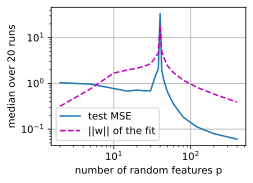

In [5]:
rng = onp.random.default_rng(0)
n, n_test, d_in, p_max, trials, noise = 40, 500, 15, 400, 20, 0.1
p_grid = onp.array([2, 5, 10, 15, 20, 25, 30, 35, 38, 40, 42, 45, 50, 60,
                    80, 120, 200, 400])
test_mse, train_mse, w_norm = (onp.zeros((trials, len(p_grid)))
                               for _ in range(3))
for tr in range(trials):
    beta = rng.standard_normal(d_in)
    beta /= onp.linalg.norm(beta)                    # teacher: y = <beta, x>
    X, X_te = (rng.standard_normal((m, d_in)) for m in (n, n_test))
    y = X @ beta + noise * rng.standard_normal(n)    # noisy training labels
    y_te = X_te @ beta
    V = rng.standard_normal((p_max, d_in)) / onp.sqrt(d_in)
    Phi, Phi_te = onp.maximum(X @ V.T, 0), onp.maximum(X_te @ V.T, 0)
    for j, p in enumerate(p_grid):                   # nested feature prefixes
        w = onp.linalg.pinv(Phi[:, :p]) @ y  # least-squares/min-norm solution
        test_mse[tr, j] = onp.mean((Phi_te[:, :p] @ w - y_te) ** 2)
        train_mse[tr, j] = onp.mean((Phi[:, :p] @ w - y) ** 2)
        w_norm[tr, j] = onp.linalg.norm(w)
med = [onp.median(a, axis=0) for a in (test_mse, train_mse, w_norm)]
for j, p in enumerate(p_grid):
    print(f'p={p:3d}  test MSE={med[0][j]:9.4f}  train MSE={med[1][j]:9.2e}'
          f'  ||w||={med[2][j]:7.2f}')
d2l.plot(p_grid, [med[0], med[2]], 'number of random features p',
         'median over 20 runs', legend=['test MSE', '||w|| of the fit'],
         xscale='log', yscale='log')

*The classical
regime plays out first*: test error falls from $1.04$ at $p=2$ to its
classical sweet spot of about $0.68$ around $p=15$, then creeps up as
variance grows, the familiar U. *The interpolation threshold shows up in the
train column*: at $p=40=n$ the training error drops from
$5\times10^{-3}$ to $10^{-28}$ (exact interpolation, up to floating
point) and precisely there the test error erupts to $33.6$, fifty times its
classical minimum, while $\|\mathbf w\|$ jumps to $18.5$: the near-singular
square system dividing noise by $\sigma_{\min}$, just as promised. *Then the
second descent*: from $p=42$ onward the norm falls monotonically ($4.96$,
$3.64$, $2.42$, $1.70$, $1.18$, down to $0.39$ at $p=400$; the nesting
guarantees this) and the test error tracks it down through $0.65$ at
$p=50$ and $0.18$ at $p=80$ to $0.060$ at $p=400$: *ten times better than the
best underparameterized model*. Note also which curve did *not* move: train
error is zero up to floating point everywhere past the threshold (the table
prints $10^{-28}$), so no
empirical-risk-based criterion can tell these models apart; the solution norm
distinguishes them in this experiment. The Rademacher calculation motivates
looking beyond parameter count, but its relevant product also includes feature
norms and does not by itself predict this test curve. The best model in this
entire experiment is the most overparameterized one, fitting noisy data
*exactly*, with ten times more parameters than data points.

### Benign Overfitting

One puzzle remains inside the mechanism. The $p=400$ model interpolates its
noisy labels (it reproduces every corrupted $y_i$ exactly), yet its test
error is the best on the table. When does fitting noise *not* hurt? The
minimum-norm solution splits across the spectrum of the feature matrix: the
*signal* is captured along the few directions with large singular values,
while interpolating the residual *noise* is distributed (because minimizing
the norm spreads it) across the many directions with small singular values,
where each contaminates predictions at new points only faintly. Overfitting is
**benign** when the spectrum has this shape: a few strong directions to carry
the signal, plus a large reservoir of weak directions that absorb and
*average out* the noise, in effect performing implicit regularization without
a regularizer. [@Bartlett.Long.Lugosi.Tsigler.2020] make this exact for
linear regression, characterizing benignity via two effective ranks of the
covariance, and [@Belkin.Hsu.Ma.ea.2019] frame the modern regime it
explains; [@Bartlett.Montanari.Rakhlin.2021] survey the fast-growing
theory. For deep networks the picture is instructive but not settled: features
there are *learned*, reshaping the spectrum during training, and a theory that
predicts a given network's test error from first principles remains open.

## Summary

* The *Chernoff method* (Markov's inequality applied to $e^{\lambda X}$,
  then optimized over $\lambda$) converts a bound on the moment generating
  function into an exponential tail bound; for sums of independent variables
  the MGF factorizes, which is where the exponential-in-$n$ decay comes from.
* *Hoeffding's lemma* bounds the MGF of a centered variable on $[a,b]$ by
  $e^{\lambda^2(b-a)^2/8}$ (proof: the second derivative of the log-MGF is a
  tilted variance, at most $(b-a)^2/4$), and *Hoeffding's inequality* follows:
  $P(|\bar X-E\bar X|\ge t)\le 2e^{-2nt^2/(b-a)^2}$, the finite-sample bound
  behind the main book's test-set arithmetic, exponentially sharper than
  Chebyshev's $1/n$. Inverted, it gives the finite-sample confidence interval
  the equation.
  *Sub-Gaussian* variables are those obeying such an MGF
  bound; *Bernstein's inequality* refines the constant using the true
  variance and covers the sub-exponential case (squares, norms).
* In high dimension, concentration is geometry (*concentration of measure*):
  $\|\mathbf x\|/\sqrt d$
  concentrates at $1$ with failure probability $2e^{-d\varepsilon^2/8}$, so a
  Gaussian is a *thin shell*, random directions are *near-orthogonal*
  ($\cos\approx 1/\sqrt d$), pairwise distances concentrate (degrading
  nearest-neighbor contrast). In a single wide random layer, related
  concentration can make the variance calculation representative, but stability
  across many nonlinear layers needs additional dependence and Jacobian control.
* Hoeffding certifies one *pre-chosen* function; a learner chooses *after*
  seeing data, so guarantees must hold *uniformly* over the class. For finite
  classes the union bound gives deviation
  $\sqrt{\log(2|\mathcal F|/\delta)/2n}$, valid for a pool of models fixed
  before the data are drawn; genuinely adaptive test-set reuse voids the
  union bound, and its guarantees degrade faster (adaptive data analysis).
* *Rademacher complexity* (how well a class can correlate with random
  signs) bounds uniform deviations:
  $R(f)\le\hat R(f)+2\mathfrak R_n(\mathcal F)+\sqrt{\log(1/\delta)/2n}$. For
  the linear class $\{\|\mathbf w\|\le B\}$ on data with $\|\mathbf x\|\le r$
  it computes to $Br/\sqrt n$: parameter count is absent when the weight and
  data radii are held fixed. A class rich enough to fit arbitrary random signs
  has complexity near its maximum and yields a vacuous bound; the failure belongs to the crude class choice, and uniform
  convergence survives as the language of guarantees.
* *Double descent*: sweeping random features through the interpolation
  threshold $p=n$, test error follows the classical U, spikes at $p=n$ (a
  near-singular system divides noise by $\sigma_{\min}$), then descends again
  while the minimum-norm interpolant shrinks with added nested features. This
  norm trend is a mechanism and diagnostic; a formal capacity explanation must
  also track feature norms and the data-dependent selection of the solution. Interpolating noise is *benign* when a few strong
  spectral directions carry the signal and many weak ones absorb the noise.

## Exercises

1. Prove that a Rademacher variable is sub-Gaussian with variance proxy $1$:
   show $\cosh\lambda\le e^{\lambda^2/2}$ by comparing the two Taylor series
   term by term ($(2k)!\ge 2^k k!$). Conclude via the Chernoff method that an
   average of $n$ fair random signs satisfies
   $P(|\bar\varepsilon|\ge t)\le 2e^{-nt^2/2}$.
2. The proof of the equation assumed a common range $[a,b]$.
   Redo it for independent $X_i\in[a_i,b_i]$ to obtain
   $P(|\bar X-E\bar X|\ge t)\le
   2\exp\bigl(-2n^2t^2/\sum_i(b_i-a_i)^2\bigr)$, and check that it reduces to
   the equation when the ranges agree. This weighted version is
   the one the near-orthogonality argument used, with weights $u_i$.
3. **McDiarmid's inequality** [@McDiarmid.1989] extends Hoeffding from
   sums to arbitrary
   functions with *bounded differences*: if changing the $i$-th argument of
   $g(x_1,\ldots,x_n)$ moves its value by at most $c_i$, then
   $P(|g - E[g]|\ge t)\le 2\exp\bigl(-2t^2/\sum_i c_i^2\bigr)$. Take this
   statement on faith (its proof needs martingales). (i) Recover Hoeffding's
   inequality from it. (ii) The bootstrap of that section
   computes a statistic of $n$ data points; argue that if that statistic has
   bounded differences $c_i=c/n$, the bootstrap's *ideal* target (the
   statistic's deviation from its mean) already concentrates at rate
   $e^{-2nt^2/c^2}$, and check the median of a sample does *not* have small
   bounded differences in general.
4. Compute the Rademacher complexity of the $\ell_1$-ball class
   $\mathcal F=\{\mathbf x\mapsto\langle\mathbf w,\mathbf x\rangle:
   \|\mathbf w\|_1\le B\}$ on data with $\|\mathbf x_i\|_\infty\le r$. The
   supremum step now uses the duality between the $\ell_1$ and $\ell_\infty$
   norms, giving $\frac Bn E\|\sum_i\varepsilon_i\mathbf x_i\|_\infty$; bound
   the expected max of $d$ sub-Gaussian coordinates to conclude
   $\widehat{\mathfrak R}_S\le Br\sqrt{2\log(2d)/n}$. Why does dimension now
   enter, and only logarithmically?
5. Rerun the double-descent sweep with ridge regression,
   $\mathbf w_\lambda=(\boldsymbol\Phi^\top\boldsymbol\Phi+
   \lambda\mathbf I)^{-1}\boldsymbol\Phi^\top\mathbf y$, for
   $\lambda\in\{10^{-8},10^{-4},10^{-2},1\}$. Watch the interpolation peak
   melt as $\lambda$ grows, and explain why using
   that section: the ridge term lifts
   $\sigma_{\min}^2$ to $\sigma_{\min}^2+\lambda$, capping the noise
   amplification. Verify numerically that as $\lambda\to0$ the ridge solution
   converges to the pseudoinverse (minimum-norm) solution.
6. In the double-descent experiment, vary the label noise
   ($\textrm{noise}\in\{0,\ 0.1,\ 0.5,\ 1.0\}$) and measure the height and
   location of the peak. Confirm that the peak stays at $p=n$ (its location
   is a rank condition, independent of the labels) while its height grows
   with the noise variance, and explain both observations with the
   $\sigma_{\min}$ mechanism. What happens to the peak when
   $\textrm{noise}=0$, and why is it not entirely gone?
7. Use the equation to find the smallest dimension $d$
   at which the shell $(1\pm 0.01)\sqrt d$ is guaranteed to hold at least
   $99\%$ of a standard Gaussian's mass, then estimate the true smallest $d$
   by simulation. How large is the gap, and which side of the story (rate or
   constant) does it come from?
8. An analyst fixes a pool of $m$ models *before* seeing the data, evaluates
   all of them on one validation set of $n$ points
   (losses in $[0,1]$), and reports the best score. Apply
   the equation with $\mathcal F$ the pre-registered pool to
   bound how *optimistic* the reported score can be, and evaluate the bound
   at $m=10$, $10^3$, and $10^6$ with $n=10{,}000$ and $\delta=0.05$. At what
   $m$ does the guaranteed accuracy degrade past $\pm 0.02$? Compare with the
   Bonferroni discussion of multiple testing in that section:
   which bound is doing the same job, and where do the two analyses differ?
   Finally, explain why none of this applies verbatim when each model is
   chosen after seeing the previous models' scores
   [@Dwork.Feldman.Hardt.ea.2015].

[Discussions](https://d2l.discourse.group/t/concentration-and-generalization)